In [1]:
from matplotlib import pyplot as plt
import numpy as np
from data import data
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

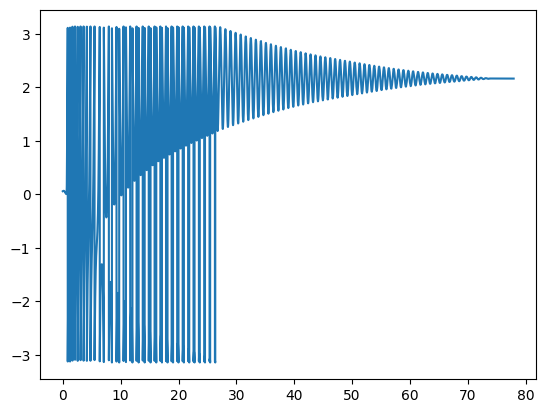

In [2]:
time, angle = list(zip(*data))

time = np.array(time)-time[0]
plt.plot(time, angle)
plt.show()

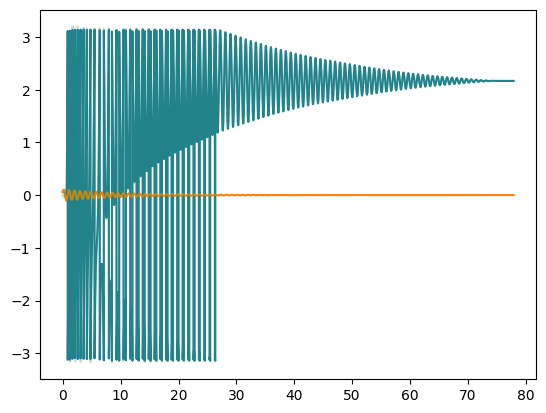

In [5]:
g = 9.81

m_bob = 10e-3#32e-3 - 10e-3
m_shaft = 48e-3
m_rod = 25e-3#30e-3

r_shaft = 8e-3/2
len = 200e-3 # 320e-3
c = 0.0002

def pendulum(t, y, params):
    """returns the full nonlinear state space derivative"""
    m_bob, m_shaft, m_rod, r_shaft, len, c = params
    th, th_dot = y

    x_dot = 0
    x_ddot = 0

    th = th%(2*np.pi)


    denom = 12*len**2*m_bob + 7*len**2*m_rod + 6*m_shaft*r_shaft**2


    th_ddot = -(12*c*th_dot + 12*g*len*m_bob*np.sin(th) + 6*g*len*m_rod*np.sin(th) + 12*len*m_bob*np.cos(th)*x_ddot + 6*len*m_rod*np.cos(th)*x_ddot)/denom 
    return np.array([th_dot, th_ddot])

y0 = [angle[0],(angle[1]-angle[0])/time[1]]
t_span = (time[0], time[-1])

def residuals(params):
    out = solve_ivp(pendulum, t_span, y0, args=[params])
    
    return np.array(angle) - np.interp(time, out.t, out.y[0]) 

p0 = [m_bob, m_shaft, m_rod, r_shaft, len, c]
out = solve_ivp(pendulum, t_span, y0, args=[p0])
plt.plot(time, angle, label='data')
plt.plot(out.t, out.y[0], label='model')
plt.plot(time, residuals(p0), label='err', alpha=0.3)

In [ ]:
cost_c = lambda p_in: np.linalg.norm(residuals([m_bob, m_shaft, m_rod, r_shaft, len, p_in[0]]))
c = minimize(cost_c, [c]).x[0]

plt.plot(time, residuals([m_bob, m_shaft, m_rod, r_shaft, len, c]), label='err_opt', alpha=0.3)
plt.legend()